# Robust iSWAP Gate — Free-Phase Version

Same setup as `robust_iswap_detuned_2MHz_100ns.ipynb` (g_eff = 2 MHz, T_total = 100 ns,
Gaussian rise/fall + flat-top with detuned drives, variational ZI/IZ/ZZ robustness),
but the per-qubit Z-phases φ_1, φ_2 are now **NLP decision variables**.

The optimizer matches `U_flat ≈ (Z(φ_1) ⊗ Z(φ_2)) · U_base` and chooses the φ's that
minimize infidelity. Mathematical caveat: single-qubit Z's do not commute with V_rise /
V_fall (which are exp(-iA(XX+YY))), so the lab-frame gate is *not* simply iSWAP
up-to-virtual-Z — we report both the optimizer's metric and the true `F(V_fall·U_flat·V_rise, iSWAP)`.

## 1. Imports

In [1]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt", "FFTW"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [2]:
using Revise
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie
using FFTW

# Internal helper for building the φ-parameterized goal as an EmbeddedOperator
import Piccolo.ProblemTemplates: _make_free_phase_goal

## 2. Parameters

In [3]:
# --- Pauli operators ---
XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

# --- Physical parameters ---
g_eff = 2π * 0.002       # flat-top coupling: 2 MHz in rad/ns
δ₁₂ = 2π * 0.06          # idle detuning: 60 MHz in rad/ns

# --- Drive detunings from gate frame (ω₁) ---
Δ_mw1 = -2π * 0.00     # 0 MHz
Δ_mw2 = +2π * 0.00     # 0 MHz

# --- Control bounds ---
a_bound = 2π * 0.01     # 10 MHz microwave amplitude bound
drive_bounds = fill(a_bound, 4)

# --- Gaussian edge parameters ---
σ_rise = 1.0            # ns

# --- Gate target ---
U_iswap = exp(-im * π/4 * (XX + YY))

# --- Optimization parameters ---
F_threshold = 0.9999
Q_r = 1e2
T_total_ns  = 100.0     # total flat-top duration (ns) — matches 2MHz_100ns folder
n_samples = 300
N_knots = 12
num_iter = 1000

println("g_eff = ", round(g_eff/(2π)*1e3, digits=1), " MHz")
println("δ₁₂ = ", round(δ₁₂/(2π)*1e3, digits=1), " MHz")
println("Δ_mw1 = ", round(Δ_mw1/(2π)*1e3, digits=1), " MHz")
println("Δ_mw2 = ", round(Δ_mw2/(2π)*1e3, digits=1), " MHz")
println("a_bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")
println("σ_rise = ", σ_rise, " ns")

g_eff = 2.0 MHz
δ₁₂ = 60.0 MHz
Δ_mw1 = -0.0 MHz
Δ_mw2 = 0.0 MHz
a_bound = 10.0 MHz
σ_rise = 1.0 ns


## 3. Compute V_rise, V_fall, and U_goal

In [4]:
buffer_duration = 4 * σ_rise
dt_fine = 0.01

t_rise = collect(0:dt_fine:buffer_duration)
g_rise = g_eff .* exp.(-(t_rise .- buffer_duration).^2 ./ (2 * σ_rise^2))

t_fall = collect(0:dt_fine:buffer_duration)
g_fall = g_eff .* exp.(-(t_fall).^2 ./ (2 * σ_rise^2))

A_rise = sum(g_rise) * dt_fine
A_fall = sum(g_fall) * dt_fine

println("A_rise = ", A_rise, " rad")
println("A_fall = ", A_fall, " rad")

θ_goal = π/4 - A_rise - A_fall
@assert θ_goal > 0

println("θ_goal = ", θ_goal, " rad")

# --- Flat-top target as a Matrix and as an EmbeddedOperator (for free_phase) ---
U_goal_mat = exp(-im * θ_goal * (XX + YY))
U_goal     = EmbeddedOperator(U_goal_mat, 1:4, [2, 2])  # full subspace, 2-qubit

V_rise = exp(-im * A_rise * (XX + YY))
V_fall = exp(-im * A_fall * (XX + YY))

U_total = V_fall * U_goal_mat * V_rise
F_check = abs(tr(U_iswap' * U_total)) / 4
println("Verification F(V_fall · U_goal · V_rise, iSWAP) = ", F_check)

T_flat_est = θ_goal / g_eff
println("Estimated flat-top duration (coupling only): ", round(T_flat_est, digits=2), " ns")

g_eff_MHz       = round(Int, g_eff/(2π)*1e3)
T_total_flat_ns = round(Int, T_total_ns)
run_tag         = "free_phase_$(g_eff_MHz)MHz_$(T_total_flat_ns)ns"
println("T_total_ns = ", T_total_ns, " ns")

A_rise = 0.015811465116606815 rad
A_fall = 0.015811465116606815 rad
θ_goal = 0.7537752331642347 rad
Verification F(V_fall · U_goal · V_rise, iSWAP) = 1.0
Estimated flat-top duration (coupling only): 59.98 ns
T_total_ns = 100.0 ns


## 4. Gate Frame Hamiltonian

In [5]:
function H_gate_frame(u, t)
    uX1, uY1, uX2, uY2 = u
    H = g_eff * (XX + YY)
    c1 = cos(Δ_mw1 * t); s1 = sin(Δ_mw1 * t)
    H += uX1 * (XI * c1 + YI * s1)
    H += uY1 * (YI * c1 - XI * s1)
    c2 = cos(Δ_mw2 * t); s2 = sin(Δ_mw2 * t)
    H += uX2 * (IX * c2 + IY * s2)
    H += uY2 * (IY * c2 - IX * s2)
    return H
end

H_vars = [
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

varsys = VariationalQuantumSystem(
    H_gate_frame, H_vars, 4, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels,
        "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars),
        "  time_dep = ", varsys.time_dependent)

levels = 4  n_drives = 4  n_vars = 3  time_dep = true


## 5. Robust + Free-Phase Optimization

In [6]:
T_f = T_total_ns
Δt = T_f / N_knots

Random.seed!(42)
controls = 2 .* a_bound .* rand(4, n_samples) .- a_bound
times = collect(LinRange(0.0, T_f, n_samples))

du_init = zeros(4, n_samples)
pulse = CubicSplinePulse(controls, du_init, times)

qcp = VariationalSplinePulseProblem(
    varsys, pulse, U_goal, N_knots;
    Q                     = 2.0,
    Q_r                   = Q_r,
    R                     = 1e-3,
    du_bound              = Inf,
    Δt_bounds             = (Δt, Δt),
    dynamics_spline_order = 3,
    n_path_samples        = 3,
    free_phase            = true,
    initial_phases        = [0.0, 0.0],
    piccolo_options       = PiccoloOptions(
        timesteps_all_equal = true,
        verbose             = true,
    ),
)

# Free-phase aware fidelity constraint: target depends on (φ_1, φ_2)
U_goal_fn = _make_free_phase_goal(U_goal)
push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal_fn, :Ũ⃗, [:φ_1, :φ_2], F_threshold, get_trajectory(qcp))
)

println("Trajectory components: ", keys(get_trajectory(qcp).components))
println("Global components: ", keys(get_trajectory(qcp).global_components))
println("Initial Δt: ", Δt, " ns")

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
    free_phase=true: added phase variables [:φ_1, :φ_2]
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
    added GlobalBoundsConstraint for :φ_1 with bounds ([-6.283185307179586], [6.283185307179586])
    added GlobalBoundsConstraint for :φ_2 with bounds ([-6.283185307179586], [6.283185307179586])
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283
Trajectory components: (:Ũ⃗, :Δt, :t, :u, :du, :var_Ũ⃗)
Global components: (:φ_1, :φ_2)
Initial Δt: 8.333333333333334 ns


In [7]:
# Initialize unitary trajectory with a consistent rollout
let
    traj    = get_trajectory(qcp)
    us      = traj[:u]
    dus     = traj[:du]
    ts      = vec(traj[:t])
    iso_dim = traj.dims[:Ũ⃗]

    nominal_sys = QuantumSystem(H_gate_frame, drive_bounds; time_dependent=true)
    nlp_pulse   = CubicSplinePulse(us, dus, ts)
    # Initialize against the bare U_base (φ=0); optimizer is free to deviate
    nlp_qtraj   = UnitaryTrajectory(nominal_sys, nlp_pulse, U_goal_mat)

    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    traj.data[traj.components[:Ũ⃗], :] .= Ũ⃗_init
    rows_var = traj.components[:var_Ũ⃗]
    traj.data[rows_var[1:iso_dim], :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal_mat' * U_init)) / varsys.levels^2
    @printf("Initial fidelity (rollout init, φ=0): %.6f\n", F0)
end

Initial fidelity (rollout init, φ=0): 0.032627


In [8]:
solve!(qcp, max_iter=num_iter, print_level=5,
    options=IpoptOptions(eval_hessian=false,
        output_file="ipopt_$(run_tag).log"))

    initializing optimizer...
      building evaluator: 2 integrators, 2 nonlinear constraints
      dynamics constraints: 1760, nonlinear constraints: 265
        integrator 1 jacobian structure: 0.116s
        integrator 2 jacobian structure: 0.03s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.51s
        constraint 2 (NonlinearGlobalKnotPointConstraint) jacobian structure: 0.949s
      jacobian structure: 601338 nonzeros (1.619s)
        integrator 1 hessian structure: 0.034s
        integrator 2 hessian structure: 0.047s
        constraint 1 (CubicHermitePathConstraint) hessian structure: 1.651s
        constraint 2 (NonlinearGlobalKnotPointConstraint) hessian structure: 7.539s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (GlobalKnotPointObjective): 0.181s
          sub-objective 2 (QuadraticRegularizer): 0.094s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (KnotPointObje

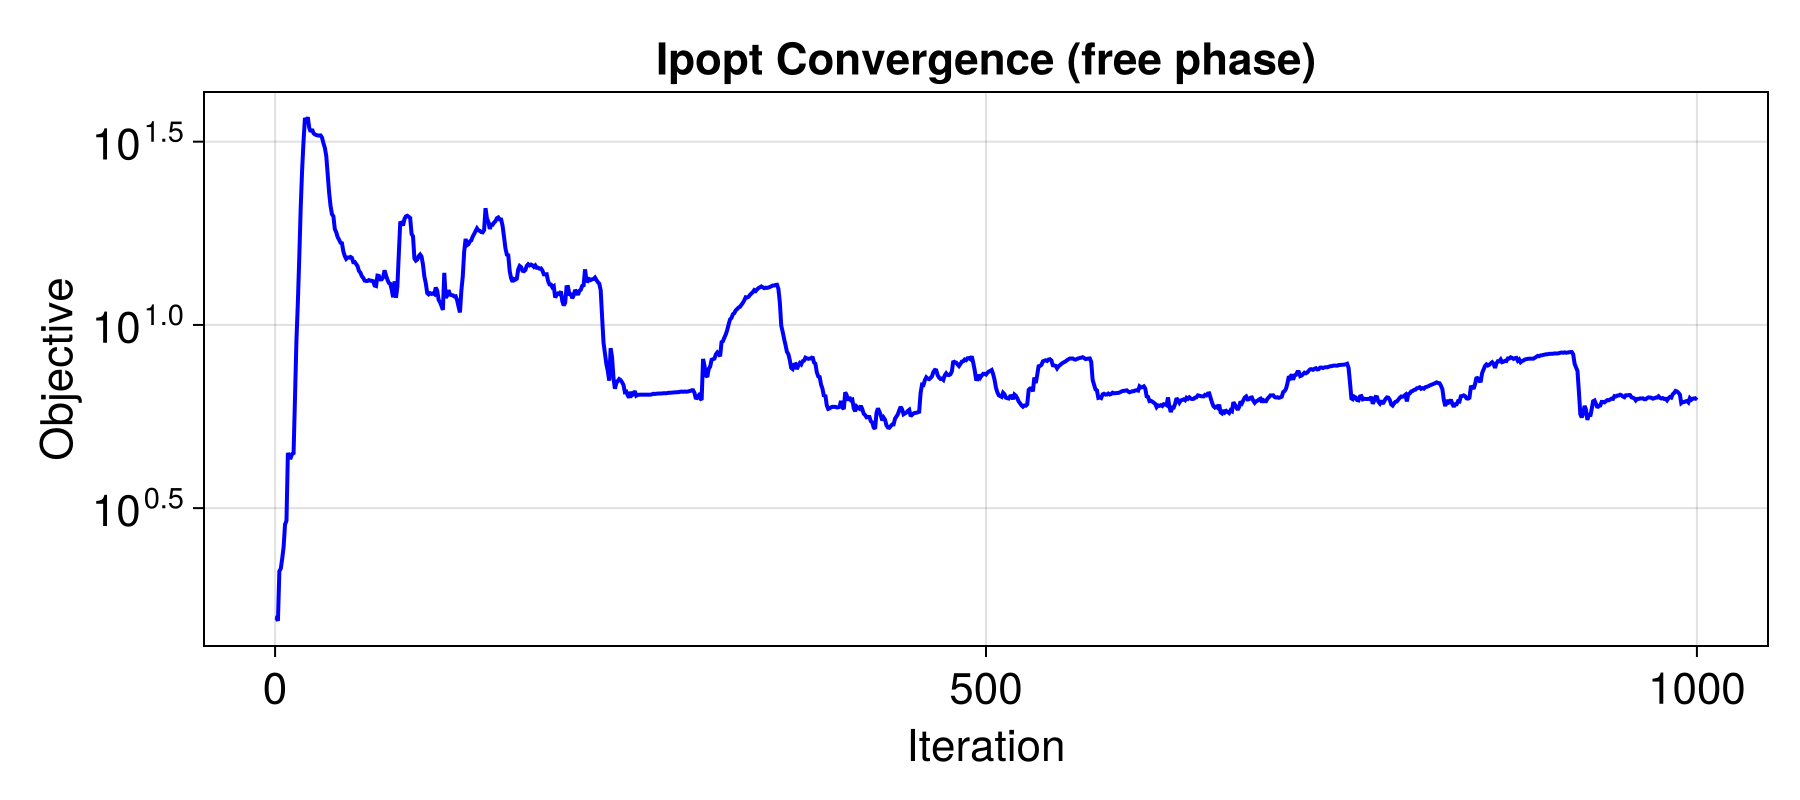

Final objective: 6.3478101 at iteration 1000


In [9]:
log_path = "ipopt_$(run_tag).log"
lines_log = readlines(log_path)

iters = Int[]
objs = Float64[]
for line in lines_log
    m = match(r"^\s*(\d+)\s+([\d.e+\-]+)\s+", line)
    if m !== nothing
        push!(iters, parse(Int, m.captures[1]))
        push!(objs, parse(Float64, m.captures[2]))
    end
end

fig = Figure(fontsize=22, size=(900, 400))
ax = Axis(fig[1, 1], xlabel="Iteration", ylabel="Objective",
    title="Ipopt Convergence (free phase)", yscale=log10)
lines!(ax, iters, objs; linewidth=2, color=:blue)
display(fig)
println("Final objective: ", objs[end], " at iteration ", iters[end])

## 6. Results — extract optimized phases and compute fidelities

In [28]:
φ_1 = traj.global_data[traj.global_components[:φ_1]][1]
φ_2 = traj.global_data[traj.global_components[:φ_2]][1]

6.1136511382186205

In [10]:
traj = get_trajectory(qcp)
U_flat = iso_vec_to_operator(traj[:Ũ⃗][:, end])

# --- Optimized phases ---
φ_1 = traj.global_data[traj.global_components[:φ_1]][1]
φ_2 = traj.global_data[traj.global_components[:φ_2]][1]
@printf("Optimized phases: φ_1 = %.6f rad (%.4f × 2π), φ_2 = %.6f rad (%.4f × 2π)\n",
    φ_1, φ_1/(2π), φ_2, φ_2/(2π))

# --- Z(φ_1) ⊗ Z(φ_2) phase factor ---
Zφ1 = Diagonal(ComplexF64[1.0, exp(im*φ_1)])
Zφ2 = Diagonal(ComplexF64[1.0, exp(im*φ_2)])
ZZφ = kron(Zφ1, Zφ2)

# --- Optimizer's metric: F(U_flat, (Z⊗Z)·U_base) ---
U_goal_phased = ZZφ * U_goal_mat
F_flat_phased = abs2(tr(U_goal_phased' * U_flat)) / varsys.levels^2
@printf("Flat-top fidelity to phase-rotated goal (Z⊗Z)·U_base: %.8f\n", F_flat_phased)
@printf("  infidelity: %.2e\n", 1 - F_flat_phased)

# --- Fidelity to bare U_base (no virtual Z) — diagnostic only ---
F_flat_bare = abs2(tr(U_goal_mat' * U_flat)) / varsys.levels^2
@printf("Flat-top fidelity to U_base (no phase rot): %.8f\n", F_flat_bare)

# --- Lab-frame full gate vs iSWAP ---
U_full = V_fall * U_flat * V_rise
F_full = abs2(tr(U_iswap' * U_full)) / 16
@printf("Full gate F(V_fall · U_flat · V_rise, iSWAP): %.8f\n", F_full)
@printf("  infidelity: %.2e\n", 1 - F_full)

# --- Lab-frame full gate vs (Z⊗Z)·iSWAP (phase-corrected target) ---
U_iswap_phased = ZZφ * U_iswap
F_full_phased = abs2(tr(U_iswap_phased' * U_full)) / 16
@printf("Full gate F(V_fall · U_flat · V_rise, (Z⊗Z)·iSWAP): %.8f\n", F_full_phased)

println("Optimized Δt: ", traj[:t][2] - traj[:t][1], " ns")
println("Optimized T_flat: ", traj[:t][end], " ns")
T_total = buffer_duration + traj[:t][end] + buffer_duration
println("Total gate time (rise + flat + fall): ", round(T_total, digits=2), " ns")

# Virtual Z: combines δ₁₂·T_total (frame correction) and the optimized φ_2
φ_vz_q1 = φ_1
φ_vz_q2 = δ₁₂ * T_total + φ_2
println("Virtual Z on q1: Rz(", round(φ_vz_q1, digits=4), " rad)")
println("Virtual Z on q2: Rz(", round(φ_vz_q2, digits=4), " rad)")

Optimized phases: φ_1 = -6.252874 rad (-0.9952 × 2π), φ_2 = 6.113651 rad (0.9730 × 2π)
Flat-top fidelity to phase-rotated goal (Z⊗Z)·U_base: 0.99911028
  infidelity: 8.90e-04
Flat-top fidelity to U_base (no phase rot): 0.98949819
Full gate F(V_fall · U_flat · V_rise, iSWAP): 0.98949819
  infidelity: 1.05e-02
Full gate F(V_fall · U_flat · V_rise, (Z⊗Z)·iSWAP): 0.99916149
Optimized Δt: 8.333333333333334 ns
Optimized T_flat: 91.66666666666667 ns
Total gate time (rise + flat + fall): 99.67 ns
Virtual Z on q1: Rz(-6.2529 rad)
Virtual Z on q2: Rz(43.6871 rad)


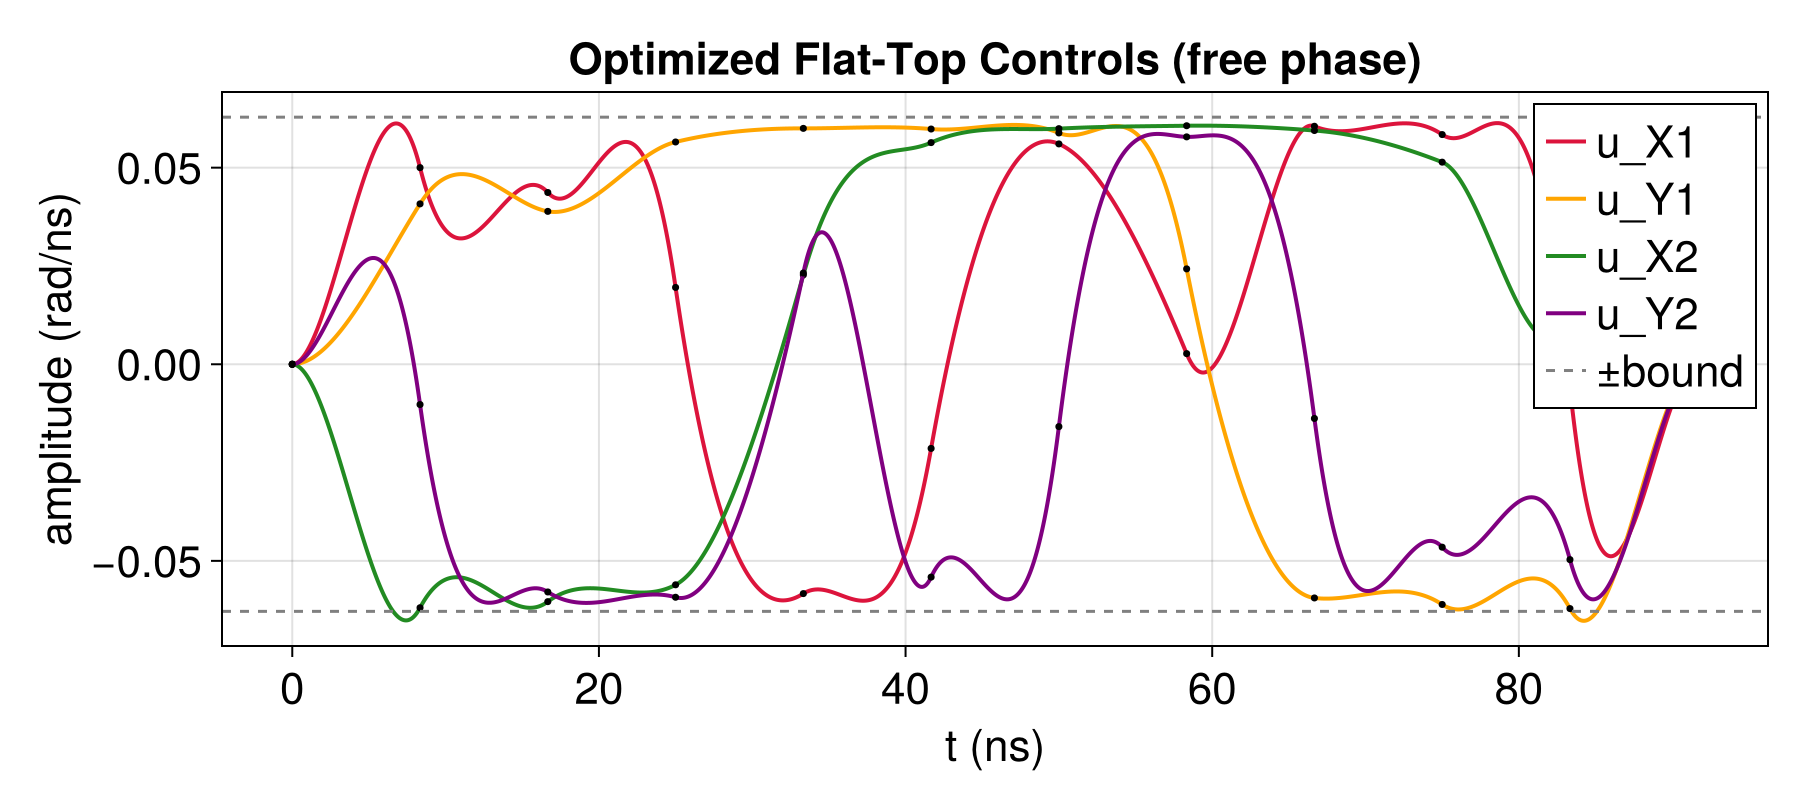

CairoMakie.Screen{IMAGE}


In [11]:
function _spline_fine(traj)
    ts_knots = vec(traj[:t])
    us_knots = traj[:u]
    du_knots = traj[:du]
    pulse    = CubicSplinePulse(us_knots, du_knots, ts_knots)
    ts_fine  = collect(LinRange(ts_knots[1], ts_knots[end], 2000))
    us_fine  = sample(pulse, ts_fine)
    return ts_knots, us_knots, ts_fine, us_fine
end

ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)

labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]

fig = Figure(size=(900, 400), fontsize=22)
ax = Axis(fig[1, 1], xlabel="t (ns)", ylabel="amplitude (rad/ns)",
    title="Optimized Flat-Top Controls (free phase)")

for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
    lines!(ax, ts_fine, vec(us_fine[i, :]); label=lbl, color=col, linewidth=2)
    scatter!(ax, ts_knots, vec(us_knots[i, :]); color=:black, markersize=5)
end
hlines!(ax, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")
axislegend(ax, position=:rt)
display(fig)

## 6b. Default Baseline: Gaussian Square (no microwaves, no free phase)

In [12]:
function gaussian_square_area(flat_ns; g_eff=g_eff, σ=σ_rise, dt=0.01, trunc=4)
    buf = trunc * σ
    t_rise = collect(0:dt:buf)
    g_rise_seg = g_eff .* exp.(-(t_rise .- buf).^2 ./ (2σ^2))
    A_rise = sum(g_rise_seg) * dt
    A_flat = g_eff * flat_ns
    A_fall = A_rise
    return A_rise + A_flat + A_fall
end

let target = π/4, lo = 0.0, hi = 400.0
    for _ in 1:100
        mid = (lo + hi) / 2
        gaussian_square_area(mid) < target ? (lo = mid) : (hi = mid)
    end
    global flat_default = (lo + hi) / 2
end

buf = 4 * σ_rise
dt_default = 0.01
T_default = buf + flat_default + buf

t_default = collect(0:dt_default:T_default)
g_default = zeros(length(t_default))
for (i, t) in enumerate(t_default)
    if t < buf
        g_default[i] = g_eff * exp(-(t - buf)^2 / (2σ_rise^2))
    elseif t < buf + flat_default
        g_default[i] = g_eff
    else
        t_fall = t - buf - flat_default
        g_default[i] = g_eff * exp(-t_fall^2 / (2σ_rise^2))
    end
end

println("Default total gate time: ", round(T_default, digits=2), " ns")

Default total gate time: 67.98 ns


## 7. Robustness Verification: Default vs Robust (free-phase aware)

Each ε-sweep point compares the lab-frame `V_fall · U_flat_err · V_rise` against
`(Z(φ_1) ⊗ Z(φ_2)) · iSWAP` (the phase-corrected target). This is the experimentally
meaningful fidelity once the φ's are absorbed into the qubit tracking frames.

In [13]:
εs         = collect(range(-0.02, 0.02, length=101))
errors     = [(ZI, "ZI"), (IZ, "IZ"), (ZZ, "ZZ")]
err_colors = [:red, :blue, :green]

F_vs_eps         = Dict{String, Vector{Float64}}()
F_default_vs_eps = Dict{String, Vector{Float64}}()

outdir = "robust_iswap_$(run_tag)"
mkpath(joinpath(outdir, "figs"))

"robust_iswap_free_phase_2MHz_100ns/figs"

In [24]:
function simulate_edge_unitary(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]
    function H_edge_err(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end
    edge_sys = QuantumSystem(H_edge_err, Float64[]; time_dependent=true)
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj = UnitaryTrajectory(edge_sys, dummy_pulse, Matrix{ComplexF64}(I, 4, 4))
    return qtraj(T_ns)
end

dt_edge = 0.01
buf = 4 * σ_rise

t_rise_fine = collect(0:dt_edge:buf)
g_rise_fine = g_eff .* exp.(-(t_rise_fine .- buf).^2 ./ (2 * σ_rise^2))

t_fall_fine = collect(0:dt_edge:buf)
g_fall_fine = g_eff .* exp.(-(t_fall_fine).^2 ./ (2 * σ_rise^2))

function simulate_full_gate_fidelity(traj, ε_op, ε_val)
    V_rise_err = simulate_edge_unitary(g_rise_fine, t_rise_fine, dt_edge, ε_op, ε_val)
    V_fall_err = simulate_edge_unitary(g_fall_fine, t_fall_fine, dt_edge, ε_op, ε_val)

    ts  = vec(traj[:t])
    us  = traj[:u]
    dus = traj[:du]

    function H_with_error(u, t)
        return H_gate_frame(u, t) + ε_val * ε_op
    end

    err_sys    = QuantumSystem(H_with_error, drive_bounds; time_dependent=true)
    nlp_pulse  = CubicSplinePulse(us, dus, ts)
    qtraj      = UnitaryTrajectory(err_sys, nlp_pulse, U_goal_mat)
    U_flat_err = qtraj(ts[end])

    U_full_err = V_fall_err * U_flat_err * V_rise_err                                                                                                
    # (Z⊗Z)_φ sits INSIDE the envelope where the optimizer placed it.
    target = V_fall * ZZφ * U_goal_mat * V_rise                                                                                                      
    return abs2(tr(target' * U_full_err)) / 16                                                                                                       
end                                                                                                                                                  
       

for (err_op, err_name) in errors
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_full_gate_fidelity(traj, err_op, ε))
    end
    F_vs_eps[err_name] = F_curve
    println("Robust $err_name sweep complete")
end

Robust ZI sweep complete
Robust IZ sweep complete
Robust ZZ sweep complete


In [25]:
function simulate_default_fidelity(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]
    function H_default(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end
    def_sys = QuantumSystem(H_default, Float64[]; time_dependent=true)
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj = UnitaryTrajectory(def_sys, dummy_pulse, U_iswap)
    U_def = qtraj(T_ns)
    return abs2(tr(U_iswap' * U_def)) / 16
end

for (err_op, err_name) in errors
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_default_fidelity(g_default, t_default, dt_default, err_op, ε))
    end
    F_default_vs_eps[err_name] = F_curve
    println("Default $err_name sweep complete")
end

Default ZI sweep complete
Default IZ sweep complete
Default ZZ sweep complete


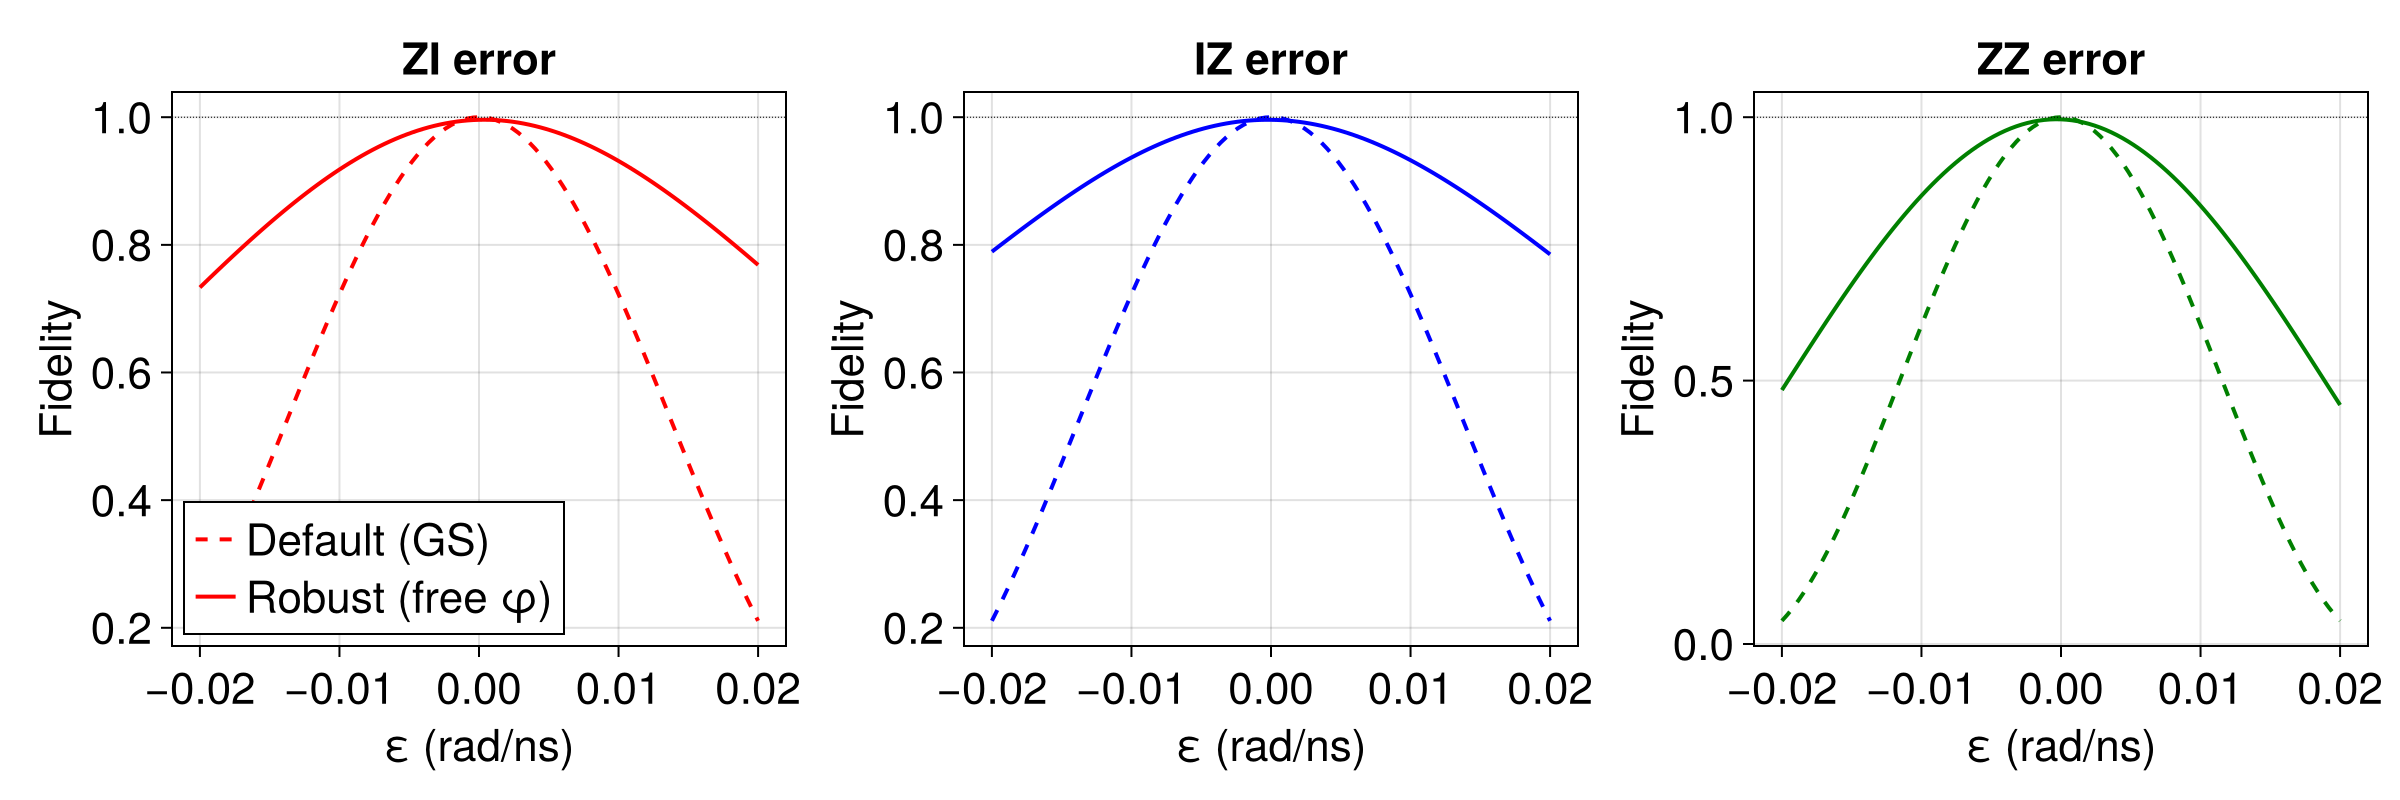

In [26]:
fig = Figure(fontsize=22, size=(1200, 400))
for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="Fidelity",
        title="$err_name error")
    lines!(ax, εs, F_default_vs_eps[err_name];
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")
    lines!(ax, εs, F_vs_eps[err_name];
        color=ecol, linewidth=2, label="Robust (free φ)")
    hlines!(ax, [F_threshold]; linestyle=:dot, color=:black, linewidth=0.5)
    if col == 1; axislegend(ax, position=:lb); end
end
display(fig)
save(joinpath(outdir, "figs", "default_vs_robust.png"), fig)

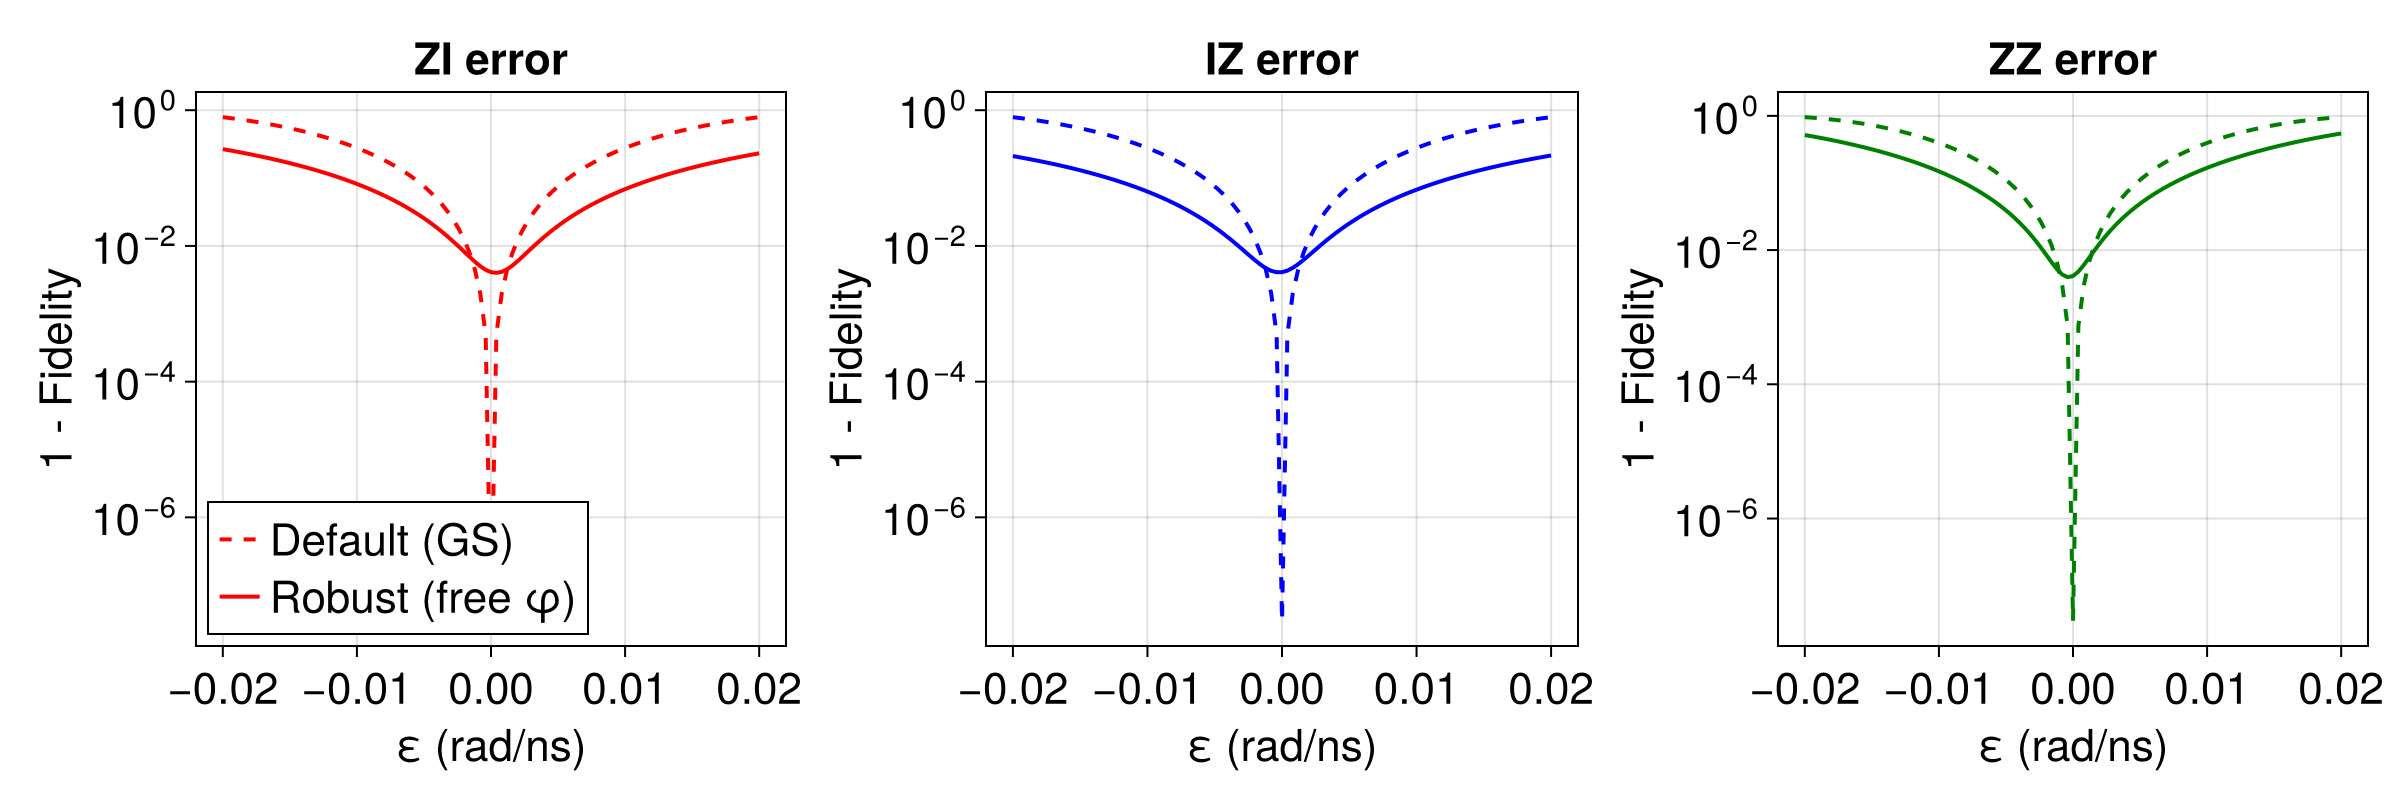

In [27]:
fig = Figure(fontsize=22, size=(1200, 400))
for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 - Fidelity",
        title="$err_name error", yscale=log10)
    lines!(ax, εs, 1 .- F_default_vs_eps[err_name];
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")
    lines!(ax, εs, 1 .- F_vs_eps[err_name];
        color=ecol, linewidth=2, label="Robust (free φ)")
    if col == 1; axislegend(ax, position=:lb); end
end
display(fig)
save(joinpath(outdir, "figs", "default_vs_robust_log.png"), fig)

## 8. Save Results

In [18]:
using DelimitedFiles

ts_knots_save, us_knots_save, ts_fine_save, us_fine_save = _spline_fine(traj)

open(joinpath(outdir, "controls_fine.csv"), "w") do io
    println(io, "time_ns,u_X1,u_Y1,u_X2,u_Y2")
    for j in 1:length(ts_fine_save)
        println(io, "$(ts_fine_save[j]),$(us_fine_save[1,j]),$(us_fine_save[2,j]),$(us_fine_save[3,j]),$(us_fine_save[4,j])")
    end
end

for (err_op, err_name) in errors
    open(joinpath(outdir, "fidelity_$(err_name).csv"), "w") do io
        println(io, "epsilon,fidelity")
        for (ε, F_val) in zip(εs, F_vs_eps[err_name])
            println(io, "$ε,$F_val")
        end
    end
end

open(joinpath(outdir, "parameters.txt"), "w") do io
    println(io, "g_eff = $g_eff rad/ns ($(round(g_eff/(2π)*1e3, digits=1)) MHz)")
    println(io, "δ₁₂ = $δ₁₂ rad/ns ($(round(δ₁₂/(2π)*1e3, digits=1)) MHz)")
    println(io, "Δ_mw1 = $Δ_mw1 rad/ns ($(round(Δ_mw1/(2π)*1e3, digits=1)) MHz)")
    println(io, "Δ_mw2 = $Δ_mw2 rad/ns ($(round(Δ_mw2/(2π)*1e3, digits=1)) MHz)")
    println(io, "a_bound = $a_bound rad/ns ($(round(a_bound/(2π)*1e3, digits=1)) MHz)")
    println(io, "σ_rise = $σ_rise ns")
    println(io, "buffer_duration = $buffer_duration ns")
    println(io, "A_rise = $A_rise rad")
    println(io, "A_fall = $A_fall rad")
    println(io, "θ_goal = $θ_goal rad")
    println(io, "T_flat = $(traj[:t][end]) ns")
    println(io, "T_total = $T_total ns")
    println(io, "F_threshold = $F_threshold")
    println(io, "free_phase = true")
    println(io, "phi_1 = $φ_1 rad")
    println(io, "phi_2 = $φ_2 rad")
    println(io, "Virtual Z on q1 = $φ_vz_q1 rad")
    println(io, "Virtual Z on q2 = $φ_vz_q2 rad")
    println(io, "F(U_flat, (Z⊗Z)·U_base) = $F_flat_phased")
    println(io, "F(V_fall·U_flat·V_rise, iSWAP) = $F_full")
    println(io, "F(V_fall·U_flat·V_rise, (Z⊗Z)·iSWAP) = $F_full_phased")
end

println("Saved to: ", abspath(outdir))

Saved to: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/robust_iswap_free_phase_2MHz_100ns
